# Clasificación: Modelos Lineales y Basados en Distancias

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/02_clasificacion_lineal_y_distancias.ipynb)


## Objetivos


- Contrastar dos enfoques opuestos de aprendizaje: el paramétrico (Regresión Logística) y el basado en memoria (KNN).
- Demostrar empíricamente por qué la falta de escalado de variables destruye el rendimiento de los modelos basados en distancias.
- Analizar el costo de inferencia y evaluar métricas de negocio (Falsos Positivos vs. Falsos Negativos) en un caso de uso real de control de acceso.



## Prerrequisitos


- Conocimientos sólidos de [Análisis Exploratorio de Datos (EDA)](../02_eda/01_introduccion_eda.ipynb).
- Haber completado: [Introducción a la Clasificación y Fronteras de Decisión](01_introduccion_clasificacion.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica



En el notebook anterior vimos cómo los algoritmos trazan fronteras de decisión. Hoy abrimos la caja negra de dos de los algoritmos más clásicos, que representan filosofías de aprendizaje completamente opuestas.



### 1. Regresión Logística (El Enfoque Paramétrico)


A pesar de su nombre, es un algoritmo de **clasificación**. Asume que el espacio puede separarse mediante una línea recta (o un hiperplano).

Durante el entrenamiento, el algoritmo busca un conjunto de "pesos" o parámetros ($w$) para cada característica ($x$). Luego, pasa esa suma ponderada por una función matemática llamada **Sigmoide** ($\sigma$), que aplasta cualquier número para que caiga exactamente entre `0` y `1`, interpretándolo como una probabilidad:

$$ P(y=1|X) = \frac{1}{1 + e^{-(w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n)}} $$

**Ventaja de Ingeniería:** Una vez entrenado, el modelo "olvida" los datos originales. Solo guarda los pesos ($w$). Para predecir un dato nuevo, solo hace una multiplicación y una suma. Es extremadamente rápido y ligero en memoria.


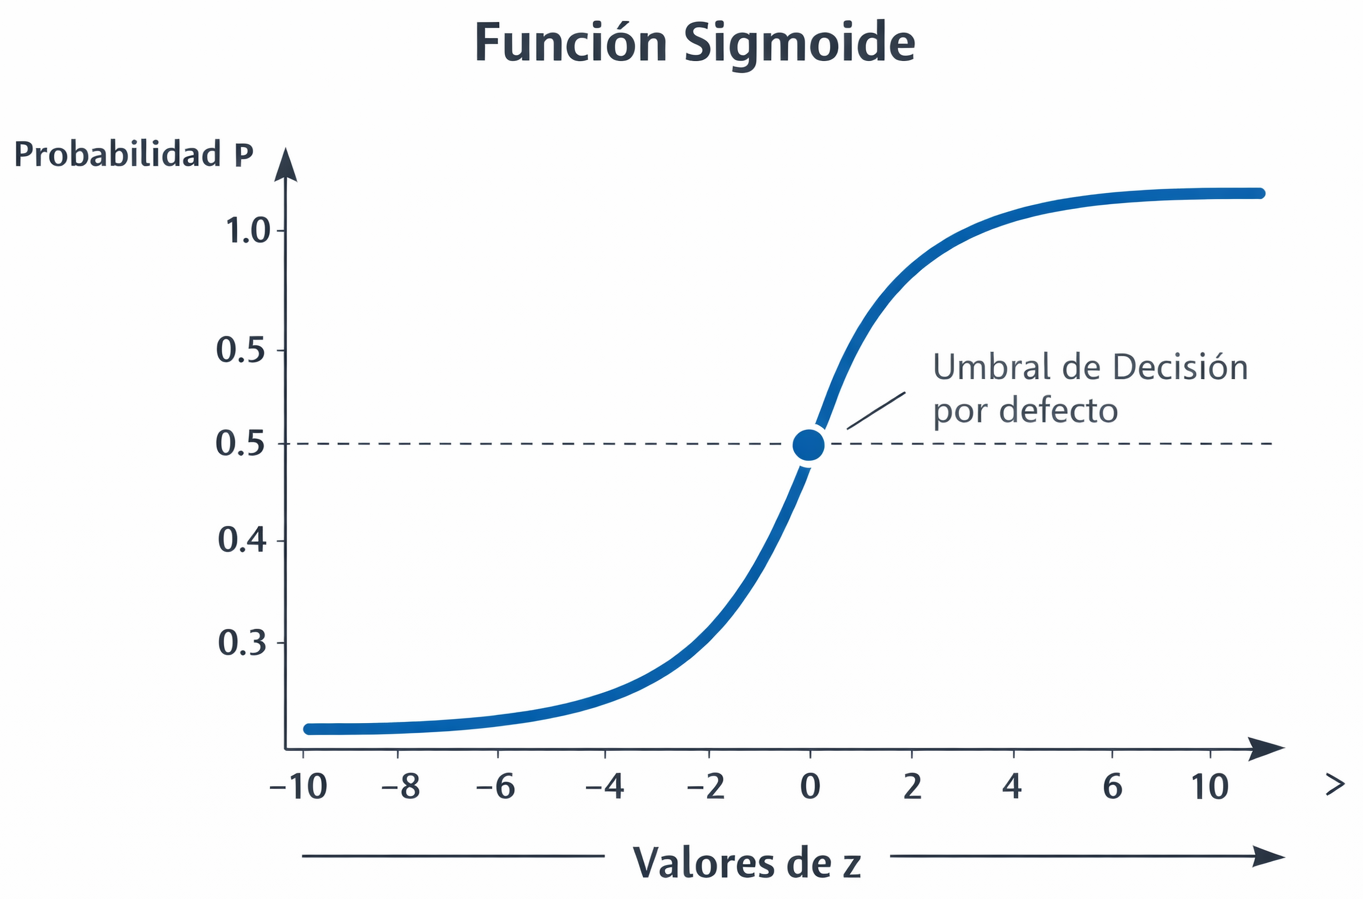

### 2. K-Nearest Neighbors (El Enfoque Basado en Memoria)


KNN no asume ninguna forma matemática. De hecho, **no tiene fase de entrenamiento real**. Simplemente guarda todos los datos en la memoria RAM.

Cuando llega un dato nuevo, calcula la distancia geométrica (usualmente la Distancia Euclidiana) entre ese nuevo punto y **todos** los puntos históricos. Luego, mira a los $K$ vecinos más cercanos y hace una votación: si la mayoría son de la Clase A, predice Clase A.

$$ Distancia = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2 + ...} $$

**Desventaja de Ingeniería:** Si se tienen un millón de usuarios como base de datos, predecir si un nuevo usuario es fraudulento requiere calcular un millón de distancias en tiempo real. Además, sufre de un problema crítico que demostraremos a continuación: la sensibilidad a la escala.



## Desarrollo e Implementación



Vamos a trabajar con el **Body Measurements Dataset (BMD)**. Imaginemos que estamos diseñando el software para una puerta de control de acceso automatizado mediante visión artificial. El sistema extrae las medidas corporales de la persona frente a la cámara y debe predecir si es un **Adulto (18 años o más)** o un **Niño**, para permitir o denegar el acceso a un área restringida.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Carga de datos usando nuestra utilidad
dataset_path = "datasets/bmd/datos_bmd.csv"
df = load_dataset(dataset_path)

# 2. Preparación del Target (Ingeniería de la variable objetivo)
# Creamos la clase binaria: 1 si es Adulto (>=18), 0 si es Niño (<18)
df['es_adulto'] = (df['Edad'] >= 18).astype(int)

# Eliminamos la Edad (para evitar Data Leakage, ya que es lo que queremos inferir)
# y el Género (asumimos que la cámara solo extrae medidas físicas en cm)
X = df.drop(columns=['Edad', 'Genero', 'es_adulto'])
y = df['es_adulto']

# División en Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Distribución de clases en Train:\n{y_train.value_counts(normalize=True) * 100}")


Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/bmd/datos_bmd.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 716 filas y 13 columnas.
Dimensiones de entrenamiento: (572, 11)
Distribución de clases en Train:
es_adulto
0    66.258741
1    33.741259
Name: proportion, dtype: float64


In [8]:
X_train.describe()

,CircunferenciaCabeza,AnchoHombro,AnchoPecho,Abdomen,Cintura,Cadera,LongitudBrazo,LongitudHombroCintura,LongitudCinturaRodilla,LongitudPierna,AlturaTotal
count,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000
mean,52.363077,36.417028,36.705664,51.399476,48.699615,49.068182,48.064615,45.413601,42.149790,68.384615,121.844510
std,9.696466,12.649580,13.370304,27.674291,23.190462,22.799395,14.109173,13.788431,13.425235,20.220395,30.444855
min,22.860000,10.160000,15.240000,12.700000,5.080000,17.780000,15.240000,2.540000,10.160000,22.860000,48.260000
25%,48.260000,27.940000,27.940000,37.465000,30.480000,30.480000,40.640000,33.020000,33.020000,53.340000,101.600000
50%,50.800000,35.560000,33.020000,50.800000,48.260000,45.720000,48.260000,45.720000,40.640000,66.040000,119.380000
75%,55.880000,45.720000,43.180000,58.420000,58.420000,60.960000,55.880000,55.880000,50.800000,81.280000,139.700000
max,203.200000,220.980000,96.520000,541.020000,231.140000,160.020000,167.640000,99.060000,114.300000,127.000000,226.060000


### El Peligro de las Escalas en KNN



Observar la fórmula de la distancia Euclidiana. ¿Qué pasa si una variable se mide en milímetros (valores de 1000 a 2000) y otra en metros (valores de 1 a 2)? La variable con números más grandes dominará completamente el cálculo de la distancia, anulando la importancia de la otra variable, sin importar su poder predictivo real.

Vamos a entrenar un KNN con los datos "crudos" y luego con los datos escalados para ver la diferencia.


> NOTA: para este dataset, **todas las medidas ya están en la misma unidad de medida**. Cada valor está expresado en centímetros (cm). Ver los rangos en el `describe()` de arriba.



In [6]:
# ⚠️ MALA PRÁCTICA: Entrenar KNN sin escalar
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
y_pred_raw = knn_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)

# ✅ BUENA PRÁCTICA: Escalar los datos primero
scaler = StandardScaler()
# Ajustamos el escalador SOLO con los datos de entrenamiento para evitar Data Leakage
X_train_scaled = scaler.fit_transform(X_train)
# Transformamos el test set usando los parámetros aprendidos del train set
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print(f"Accuracy KNN (Datos Crudos): {acc_raw:.4f}")
print(f"Accuracy KNN (Datos Escalados): {acc_scaled:.4f}")


Accuracy KNN (Datos Crudos): 0.9306
Accuracy KNN (Datos Escalados): 0.9236


El cambio de escala, implica (para este caso) una diferencia del `1%` sobre el conjunto de test. ¿Para peor encima? ¿Qué significa entonces? ¿Escalamos o no?

Tanto `pandas` como `numpy` ya están importados como para:

> Probar qué pasa si algunas variables se expresan en metros, otras en milímetros o incluso en unidades un tanto absurdas (kilómetros)...  ¿El *Accuracy* sobre los datos de test sufre?


En modelos basados en distancias (KNN, SVM, K-Means), **estandarizar las variables no es opcional, es un requisito matemático estricto.**



### Comparativa: Regresión Logística vs. KNN



Ahora, comparamos nuestro KNN escalado contra una Regresión Logística, prestando especial atención a los tiempos de inferencia.



In [9]:
# Entrenamos la Regresión Logística
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Medimos tiempo de inferencia para Regresión Logística
start_time = time.time()
y_pred_lr = log_reg.predict(X_test_scaled)
lr_infer_time = (time.time() - start_time) * 1000 # en milisegundos

# Medimos tiempo de inferencia para KNN
start_time = time.time()
_ = knn_scaled.predict(X_test_scaled)
knn_infer_time = (time.time() - start_time) * 1000 # en milisegundos

print(f"Regresión Logística - Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} | Tiempo Inferencia: {lr_infer_time:.2f} ms")
print(f"KNN (Escalado)      - Accuracy: {acc_scaled:.4f} | Tiempo Inferencia: {knn_infer_time:.2f} ms")


Regresión Logística - Accuracy: 0.8750 | Tiempo Inferencia: 0.74 ms
KNN (Escalado)      - Accuracy: 0.9236 | Tiempo Inferencia: 15.18 ms


## Resultados y Discusión: Criterio de Negocio



Hay 5 puntos porcentuales de diferencia en el *Accuracy* sobre test. Con algo de cariño, puede decirse que ambos modelos tienen un *Accuracy* "similar". Sin embargo, la Regresión Logística es órdenes de magnitud más rápida en la inferencia. Si este modelo corriera en un microcontrolador de bajo consumo en la puerta de acceso, la Regresión Logística sería la elección obvia de ingeniería. Es muy rápido, y apenas consumiría RAM. Con más datos, se podría ajustar mejor, pero KNN sería "más lento".

Pero el *Accuracy* no cuenta toda la historia. En un sistema de control de acceso, los errores no cuestan lo mismo:
- **Falso Positivo (FP):** El modelo dice que es Adulto, pero es un Niño. *Consecuencia:* Un menor ingresa a un área restringida o peligrosa. **Riesgo Crítico.**
- **Falso Negativo (FN):** El modelo dice que es Niño, pero es un Adulto. *Consecuencia:* El molinete no se abre, el adulto se molesta y debe mostrar su ID a un guardia. **Riesgo Aceptable (Fricción operativa).**

Veamos cómo se equivocó nuestra Regresión Logística usando una Matriz de Confusión:



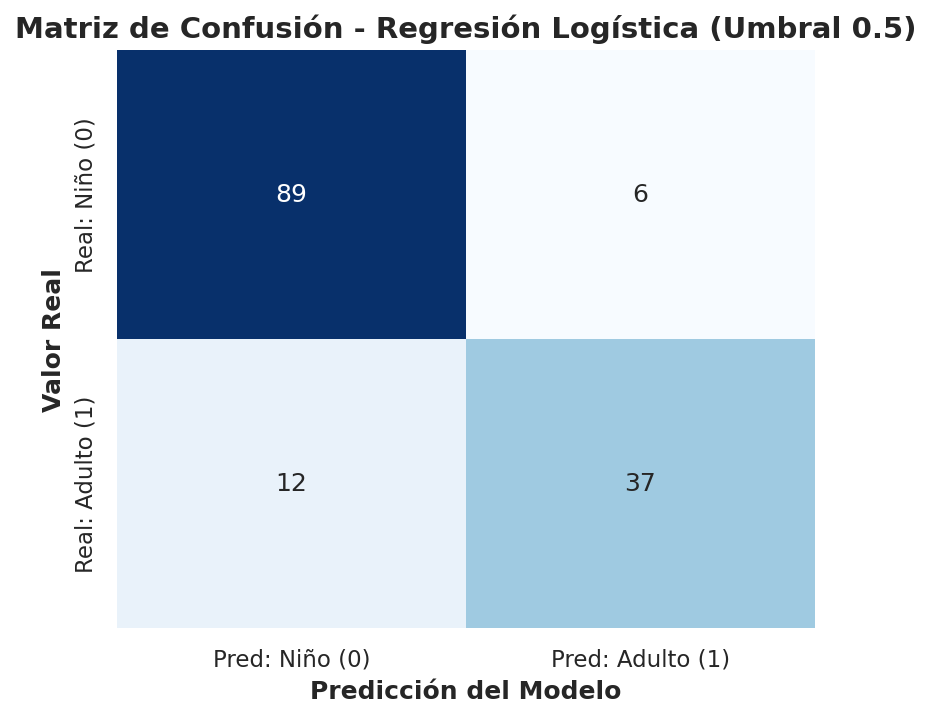

In [10]:
# Visualizamos la Matriz de Confusión de la Regresión Logística
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Niño (0)', 'Pred: Adulto (1)'],
            yticklabels=['Real: Niño (0)', 'Real: Adulto (1)'])
plt.title('Matriz de Confusión - Regresión Logística (Umbral 0.5)')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

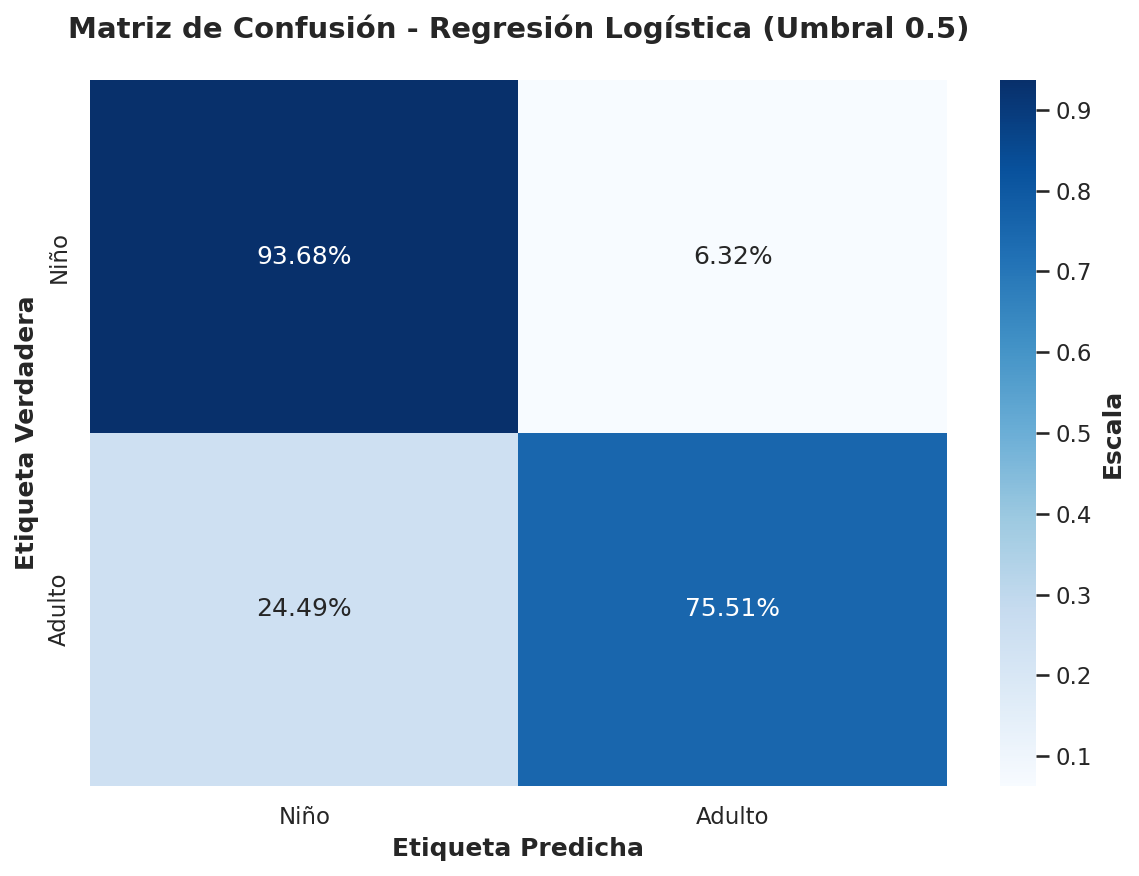

In [13]:
from utils.plots import plot_confusion_matrix

# Dentro del repositorio, tenemos codificadas algunas funciones para agilizar las
# gráficas habituales. Va ejemplo, con normalización así vemos porcentualmente los
# errores y aciertos...

plot_confusion_matrix(y_test, y_pred_lr, classes=['Niño', 'Adulto'], title='Matriz de Confusión - Regresión Logística (Umbral 0.5)', normalize=True)

### Ajustando el Umbral de Decisión



Por defecto, la Regresión Logística usa un umbral de $0.5$ (si la probabilidad es $>50\%$, predice Adulto). Pero como ingenieros, podemos modificar este umbral para hacer el sistema más estricto y reducir los Falsos Positivos a cero (idealmente), a costa de aumentar los Falsos Negativos (*gano por un lado, pero pierdo por el otro...* **tomar decisiones implica consecuencias**).



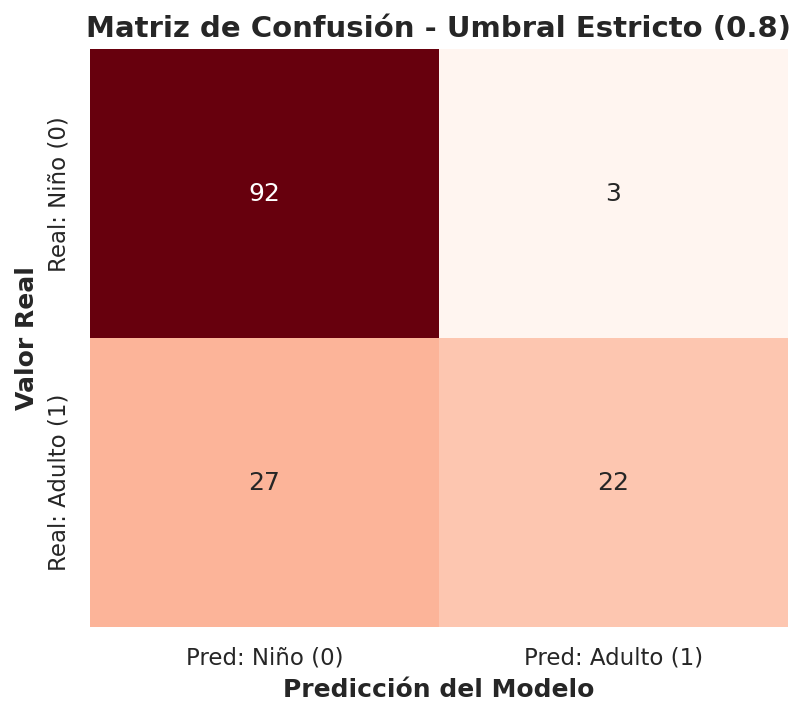

In [14]:
# Obtenemos las probabilidades crudas en lugar de la clase final
probabilidades = log_reg.predict_proba(X_test_scaled)[:, 1] # Probabilidad de ser clase 1 (Adulto)

# Definimos un umbral más estricto (ej. 80% de seguridad para abrir la puerta)
umbral_estricto = 0.80
y_pred_estricto = (probabilidades >= umbral_estricto).astype(int)

cm_estricto = confusion_matrix(y_test, y_pred_estricto)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_estricto, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Pred: Niño (0)', 'Pred: Adulto (1)'],
            yticklabels=['Real: Niño (0)', 'Real: Adulto (1)'])
plt.title(f'Matriz de Confusión - Umbral Estricto ({umbral_estricto})')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()



Al subir el umbral, le estamos diciendo al modelo: *"Solo abre la puerta si estás 80% seguro de que es un adulto"*. Observar cómo los Falsos Positivos (cuadrante superior derecho) disminuyeron ahora. Antes pasaban `6`, ahora `3`. Adaptamos el modelo matemático a la necesidad real del negocio, pero ahora... hay `27` adultos que se clasificaron como niños (cuadrante inferior izquierdo), mientras que antes esto le ocurría solamente a `12`.


> **Probar de mover el umbral** (`umbral_estricto` en el código), y analizar los nuevos resultados (desempeño). ¿Hay algún valor óptimo?


Hay mejores estrategias para hacer esto, y se conoce como "calibrar el modelo". Lo vemos más adelante.


## Conexiones y Próximos Pasos



Hemos visto que la Regresión Logística es rápida y permite ajustar umbrales probabilísticos, pero asume que los datos se pueden separar con una línea recta. ¿Qué pasa si la frontera real entre clases es un círculo o una forma compleja, pero seguimos necesitando la eficiencia de un modelo matemático?

- ➡️ **Siguiente:** En el Notebook de [Clasificación SVM y Kernels](03_clasificacion_svm_y_kernels.ipynb), descubriremos cómo las Máquinas de Vectores de Soporte utilizan un "truco" matemático para doblar el espacio y resolver problemas no lineales.



## Referencias


1. Kiru, M. (2021). *Body Measurements Datasets*. Mendeley Data.
2. [Scikit-Learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)

---


## Entorno de Ejecución


In [15]:
from utils.environment import environment_table
environment_table(include_all=False)


Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
